Code for analyzing precipitation from CM2.5-FLOR Preindustrial simulations forced with CTRL and modified topographic boundary conditions and comparing model output to a suite of observational and reanalysis products.

Relevant for manuscript Figure 3 and Supplemental Figure S6

In [1]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import xarray as xr
xr.set_options(keep_attrs=True)
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
from scipy.ndimage import gaussian_filter1d
import pyproj

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.ops import transform
from shapely.geometry import LineString

import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib import cm

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *
from domain_funcs import *

dpath0='/discover/nobackup/projects/giss/baldwin_nip/dmkumar' # top level data directory

## LOAD DATA

In [2]:
### +++ DATA PATHS +++ ###

# --- product keys --- #
keys=['obs','flor']
obs_prods=['imerg', 'trmm', 'gpcp', 'gpcc']
flor_runs=['ctrl','hitopo','hicam']

# --- store filepaths --- #
files={ 'obs':{}, 'flor':{}, 'topo':{} }
    
for key in ['obs']:
    files[key]['imerg'] = f'{dpath0}/obs_data/prec/imerg.gn.timeseries.2001-2018.nc' 
    files[key]['trmm'] = f'{dpath0}/obs_data/prec/pr_TRMM-L3_v7-7A_199801-201312.nc' 
    #files[key]['chirps'] = f'{dpath0}/obs_data/prec/chirps-v3.0.monthly.nc'
    files[key]['gpcc'] = f'{dpath0}/obs_data/prec/gpcc.precip.mon.rate.0.25x0.25.v2020.nc'
    files[key]['gpcp'] = f'{dpath0}/obs_data/prec/gpcp.precip.1979-2018.monthly.nc'

for key in ['flor']:
    for run in flor_runs:
        files[key][run] = f'{dpath0}/FLOR/{run}/pi/flor.{run}.precip.monthly.nc'

for key in ['topo']:
    files[key]['etopo'] = f'{dpath0}/topo_files/obs.etopo5.zsurf.nc'
    files[key]['ctrl'] = f'{dpath0}/topo_files/flor.ctrl.zsurf.nc'
    files[key]['hitopo'] = f'{dpath0}/topo_files/flor.hitopo.zsurf.nc'
    files[key]['hicam'] = f'{dpath0}/topo_files/flor.hicam.zsurf.nc'

In [3]:
### +++ LOAD & ORGANIZE DATA +++ ###

dat = { 'obs': {}, 'flor': {} }

# --- sub-setting bounds --- #
latmin, latmax = 10, 70
lonmin, lonmax = 200, 300
yr_min, yr_max = '0101', '0200'

# --- load & subset obs precip data --- #
print('Working on...')
for key in ['obs']:
    print(f'{key}')
    for run in obs_prods:
        if run == 'imerg':
            ds = xr.open_dataset(files[key][run], chunks={}).precipitation * 24 # convert from mm/hr to mm/day
            ds = ds.transpose('time','lat','lon')
            ds.attrs['units'] = 'mm/day'
            ds.attrs['Units'] = 'mm/day'
            ds = lonFlip(ds) # switch lons from -180:180 to 0:360
        if run == 'trmm':
            ds = xr.open_dataset(files[key][run], chunks={}).pr * 86400 # convert from kg m-2 s-1 to mm/day
        if run == 'gpcp':
            ds = xr.open_dataset(files[key][run], chunks={}).precip
        if run == 'gpcc':
            ds = xr.open_dataset(files[key][run], chunks={}).precip.sortby("lat")  # sort lats from south to north
        dat[key][run] = ds.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        del ds

# --- load & subset cm2.5-flor precip data --- #
for key in ['flor']:
    print(f'{key}')
    for run in flor_runs:
        ds = xr.open_dataset(files[key][run]).precip.sel(time=slice(yr_min, yr_max)) * 86400 
        ds = ds.rename({'grid_xt':'lon','grid_yt':'lat'}) # update coordinate names to match imerg
        ds.attrs['units'] = 'mm/day' # update units
        dat[key][run] = ds.sel(lon=slice(lonmin,lonmax), lat=slice(latmin,latmax))

print('Done.\n')

# --- load & subset topography data --- #
topo = {}
for key in ['topo']:
    for case in ['etopo']:
        ds = xr.open_dataset(files[key][case]).ROSE.rename({'ETOPO05_X':'lon', 'ETOPO05_Y':'lat'})
        topo[case] = ds.where(ds>0, np.nan).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        del ds
    for case in ['ctrl', 'hitopo', 'hicam']:
        ds = xr.open_dataset(files[key][case]).ZSURF.rename({'GRID_XT':'lon', 'GRID_YT':'lat'})
        topo[case] = ds.where(ds>0, np.nan).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        del ds
print('Topography data loaded.')

Working on...
obs
flor
Done.

Topography data loaded.


## CALCULATE TIME-MEANS
Focusing only on July-August-September because that is the peak North American Monsoon season.

In [4]:
### +++ CALCULATE TIME-MEANS +++ ###

jas_mean     = { 'obs': {}, 'flor': {} }
ann_jas_mean = { 'obs': {}, 'flor': {} }

print('Calculating seasonal means for...')
for key in ['obs']:
    print(f'{key}')
    for run in obs_prods:
        jas_mean[key][run]     = jas_seasonal_mean(dat[key][run]).load()
        ann_jas_mean[key][run] = jas_yearly_mean(dat[key][run]).load()
        
for key in ['flor']:
    print(f'{key}')
    for run in flor_runs:
        jas_mean[key][run]     = jas_seasonal_mean(dat[key][run]).load()
        ann_jas_mean[key][run] = jas_yearly_mean(dat[key][run]).load()

print('Done.')

Calculating seasonal means for...
obs
flor
Done.


## SIGNIFICANCE TESTING

In [5]:
### +++ COMPARING ALL MODEL RUNS TO OBS. +++ ###

# --- interpolate obs to FLOR grid --- #
jas_mean_regrid     = {}
ann_jas_mean_regrid = {}

print('Re-gridding obs.')
lats = dat['flor']['ctrl'].lat
lons = dat['flor']['ctrl'].lon
for prod in obs_prods:
    jas_mean_regrid[prod]     = jas_mean['obs'][prod].interp(lat=lats, lon=lons, method='linear')
    ann_jas_mean_regrid[prod] = ann_jas_mean['obs'][prod].interp(lat=lats, lon=lons, method='linear')
print('Done.')

# --- significance testing: model vs. obs --- #
diff      = {prod: {} for prod in obs_prods}
diff_mask = {prod: {} for prod in obs_prods}
ptvals    = {prod: {} for prod in obs_prods}

print('\nSignificance testing for:')
for prod in obs_prods:
    print(f'{prod}')
    for run in flor_runs:
        print(f'...{run}')
        d, m, p = sigtest2n(ann_jas_mean['flor'][run], ann_jas_mean_regrid[prod],
                            jas_mean['flor'][run],     jas_mean_regrid[prod])
        diff[prod][run]      = d
        diff_mask[prod][run] = m
        ptvals[prod][run]    = p

print('Done.')

Re-gridding obs.
Done.

Significance testing for:
imerg
...ctrl
...hitopo
...hicam
trmm
...ctrl
...hitopo
...hicam
gpcp
...ctrl
...hitopo
...hicam
gpcc
...ctrl
...hitopo
...hicam
Done.


In [6]:
### +++ COMPARING ALL MODIFIED TOPOGRAPHY MODEL RUNS TO MODEL CTRL +++ ###

flor_mod_runs = ['hitopo', 'hicam']

# --- significance testing: modified_topo vs. ctrl --- #
model_diff      = {}
model_diff_mask = {}
model_ptvals    = {}

print('Significance testing for:')
for run in flor_mod_runs:
    print(f'...{run}')
    d, m, p = sigtest2n(ann_jas_mean['flor'][run], ann_jas_mean['flor']['ctrl'],
                        jas_mean['flor'][run],     jas_mean['flor']['ctrl'])
    model_diff[run]      = d
    model_diff_mask[run] = m
    model_ptvals[run]    = p

# --- evaluate where model biases are greater than in the ctrl --- #
bias_change        = {prod: {} for prod in obs_prods}
bias_change_masked = {prod: {} for prod in obs_prods}

for prod in obs_prods:
    for run in flor_mod_runs:
        bias_change[prod][run]        = np.abs(diff[prod][run]) - np.abs(diff[prod]['ctrl'])
        bias_change_masked[prod][run] = bias_change[prod][run].where(model_diff_mask[run].notnull())

print('\nDone.')

Significance testing for:
...hitopo
...hicam

Done.


## FIGURES

In [7]:
## +++ LOAD PRE-SET SUB-DOMAIN BOUNDARIES +++ ##
coords_map, regions = nam_regions()
domains = list(coords_map.keys())

### Obs Products JAS Climatologies

In [ ]:
# -------------------- #
#       Settings       #
# -------------------- #
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array(['IMERG', 'TRMM', 'GPCP', 'GPCC'])
letters=['A','B','C','D']
tx=-110.5
ty=40.25
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=False)
dvmin=0
dvmax=11
dlevels=np.linspace(dvmin, dvmax, 23)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]


# ------------------- #
#      Make Plot      #
# ------------------- #
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(25,8), layout='constrained', subplot_kw={'projection':proj})

for i,prod in enumerate(['imerg','trmm','gpcp','gpcc']):
    obs_data = jas_mean['obs'][prod]
    lats = obs_data.lat
    lons = obs_data.lon
    cf = ax[i].pcolormesh(lons, lats, obs_data, cmap=dcmap, norm=dnorm, transform=trans)

for i, ax in enumerate(ax.flat): 
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-121, ty+0.5, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=1)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=1)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1)
    ax.add_feature(cfeature.OCEAN, facecolor='grey', linewidth=1)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=(i==0); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# colorbar
cax=fig.add_axes([1.01, 0.15, 0.02, 0.7])
cbar=fig.colorbar(cf, ticks=[1,3,5,7,9,11], orientation='vertical', extend='both', cax=cax)
cbar.set_label('Precipitation Rate [mm/day]', labelpad=25, rotation=270, size=18, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

plt.savefig('../figs/prec_climo_nam_observations.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../figs/prec_climo_nam_observations.png', transparent=False, bbox_inches='tight')

### Comparison of CTRL bias against IMERG, TRMM, GPCP, GPCC precip products

In [ ]:
# --- settings --- #
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
titles=np.array(['CTRL$-$IMERG', 'CTRL$-$TRMM', 'CTRL$-$GPCP', 'CTRL$-$GPCC'])
letters=['A','B','C','D']
tx=-110.5
ty=40.25
# var specs
lat=jas_mean['flor']['ctrl'].lat
lon=jas_mean['flor']['ctrl'].lon
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,3000,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]

# --- plot --- #
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(25,8), layout='constrained', subplot_kw={'projection':proj})

for i, prod in enumerate(obs_prods):
    cf = ax[i].pcolormesh(lon, lat, diff_mask[prod]['ctrl'], cmap=dcmap, norm=dnorm, transform=trans)

# --- formatting --- #
for i, ax in enumerate(ax.flat):
    ax.contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1.3, colors='black', transform=trans)
    poly1 = patches.Polygon(coords_map['north'], closed=True, ec='firebrick', fc='none', lw=2.5, ls='--',
                             transform=ccrs.PlateCarree(), zorder=105)
    ax.add_patch(poly1)
    poly2 = patches.Polygon(coords_map['south'], closed=True, ec='red', fc='none', lw=2.5, ls='--',
                             transform=ccrs.PlateCarree(), zorder=105)
    ax.add_patch(poly2)
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-121, ty+0.5, letters[i], **text_kw2)
    ax.coastlines(color='k', linewidth=.8)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=.8)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=.8)
    if i==3:
        ax.add_feature(cfeature.OCEAN, facecolor='grey', zorder=100)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=(i==0); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# --- colorbar --- #
cax=fig.add_axes([1.01, 0.15, 0.02, 0.7])
cbar=fig.colorbar(cf, ticks=[-3,-2,-1,0,1,2,3], orientation='vertical', extend='both', cax=cax)
cbar.set_label('Precipitation Bias [mm/day]', labelpad=25, rotation=270, size=18, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

# --- output --- #
plt.savefig('../figs/prec_flor_pi_ctrl_all-obs-prods-bias.png', transparent=False, bbox_inches='tight')
plt.savefig('../figs/prec_flor_pi_ctrl_all-obs-prods-bias.pdf', transparent=False, bbox_inches='tight')

### CTRL Prec Bias vs. IMERG & HIgbl/HImex Change

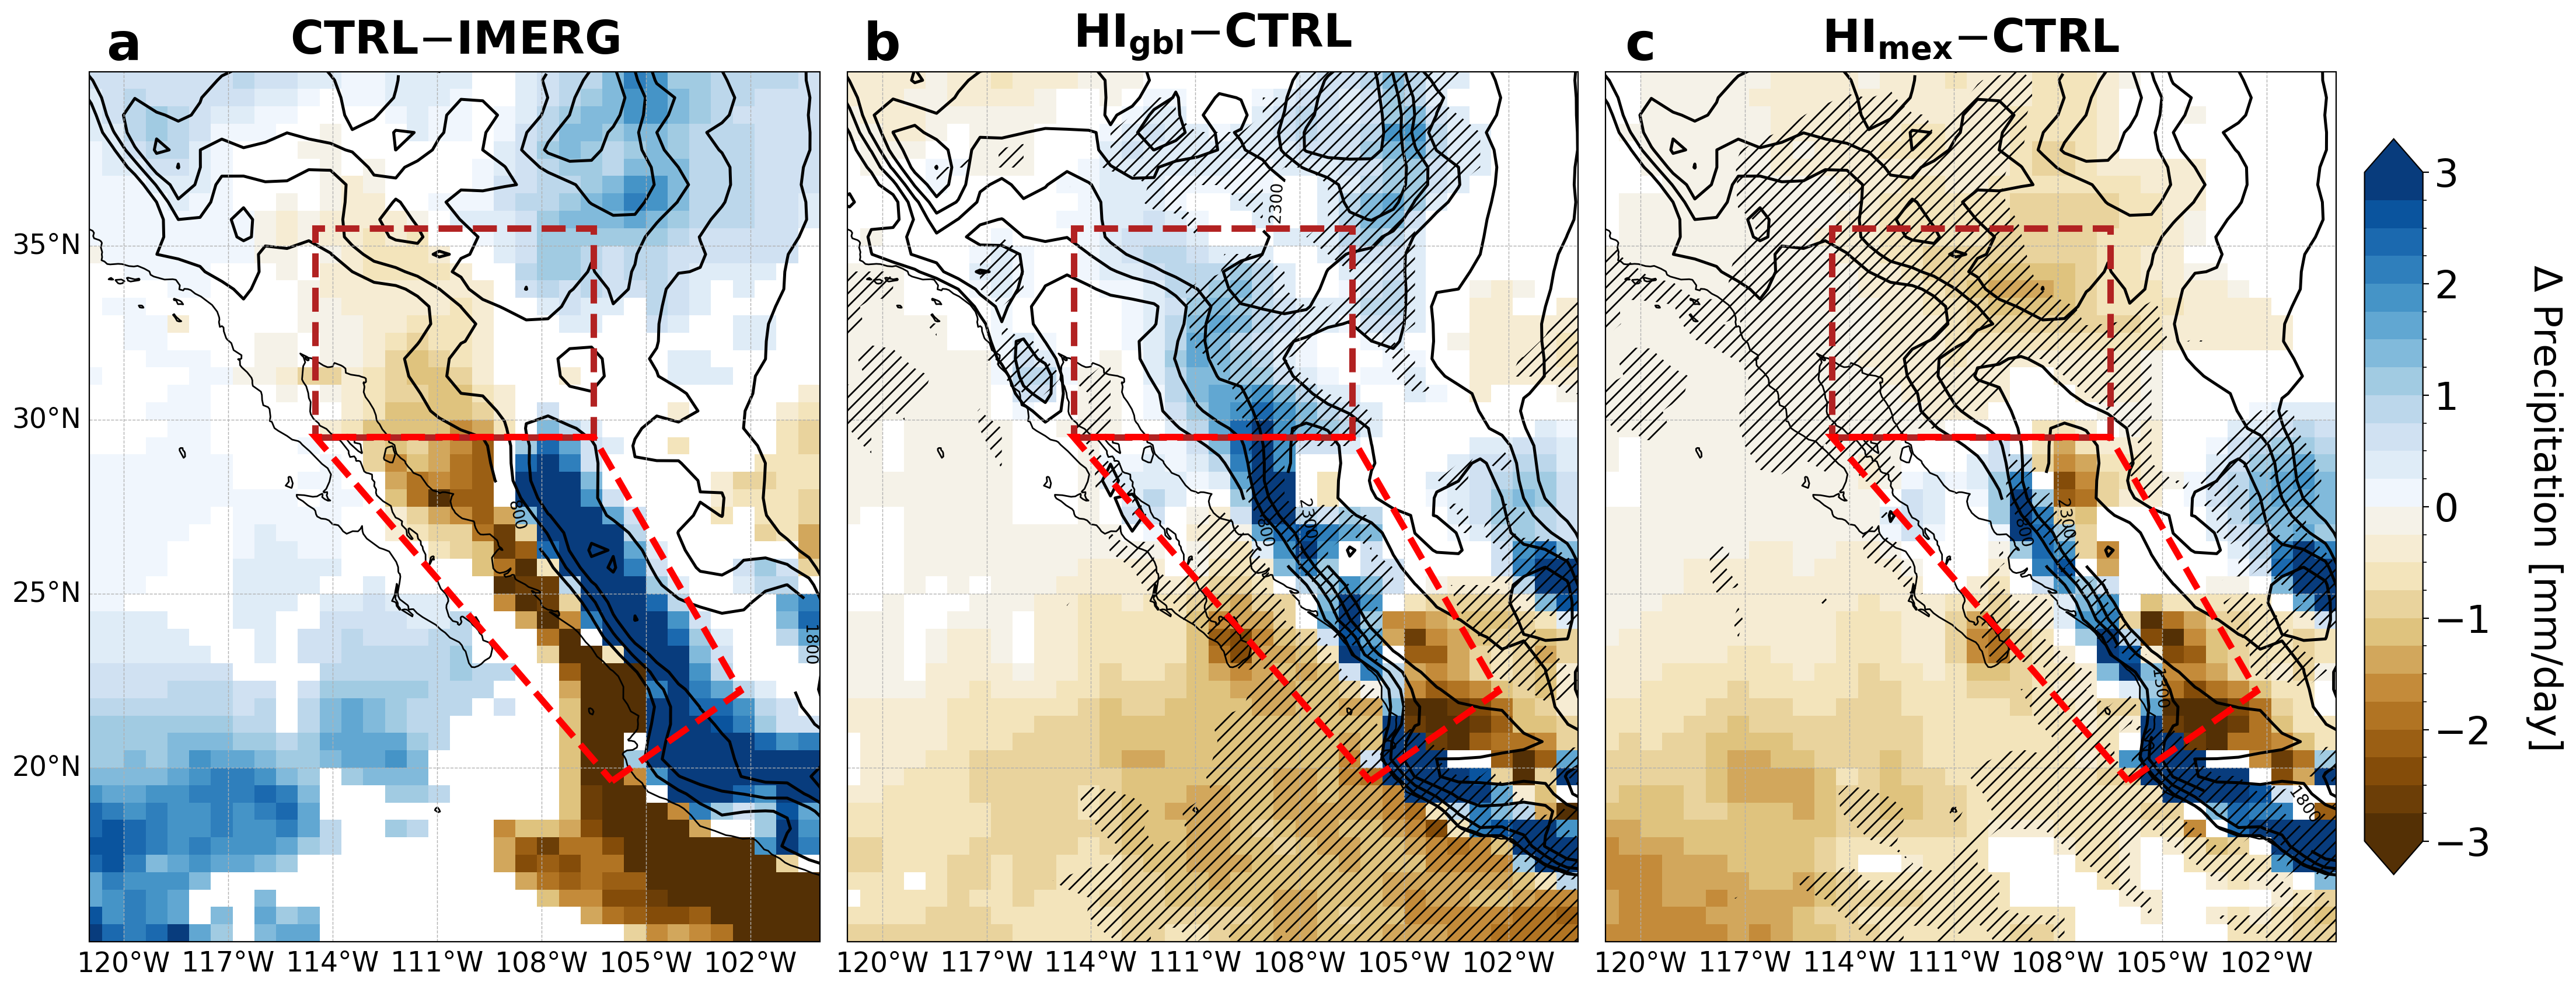

In [30]:
# --- Settings --- #
text_kw={'color':'k', 'weight':'bold', 'size':28, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':32, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array(['CTRL$-$IMERG', r'HI$_{\mathbf{gbl}}$$-$CTRL', r'HI$_{\mathbf{mex}}$$-$CTRL'])
letters=['a','b','c','d']
tx=-110.5
ty=40.25
# var specs
lat=jas_mean['flor']['ctrl'].lat
lon=jas_mean['flor']['ctrl'].lon
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(800,3800,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]

# --- Plot --- #
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,9), layout='constrained', subplot_kw={'projection':proj})

# ctrl - imerg difference (i.e., model bias)
cf=ax[0].pcolormesh(lon, lat, diff_mask['imerg']['ctrl'], cmap=dcmap, norm=dnorm, transform=trans)
cs=ax[0].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1.8, colors='black', transform=trans)
ax[0].clabel(cs, fontsize=10, inline=True, inline_spacing=-2)

for i,run in enumerate(['hitopo','hicam']):
    ax[i+1].pcolormesh(lon, lat, model_diff_mask[run], cmap=dcmap, norm=dnorm, transform=trans)
    cs=ax[i+1].contour(lon, lat, topo[run], levels=zlevels, linewidths=1.8, colors='black', transform=trans)
    ax[i+1].clabel(cs, fontsize=10, inline=True, inline_spacing=-2)
    ax[i+1].contourf(lon, lat, bias_change_masked['imerg'][run],
                     0, colors='none', hatches=['','///'], extend='lower', zorder=100, transform=trans)

# --- formatting --- #
for i, ax in enumerate(ax.flat):
    poly1 = patches.Polygon(coords_map['north'], closed=True, ec='firebrick', fc='none', lw=4, ls='--',
                             transform=ccrs.PlateCarree(), zorder=100)
    ax.add_patch(poly1)
    poly2 = patches.Polygon(coords_map['south'], closed=True, ec='red', fc='none', lw=4, ls='--',
                             transform=ccrs.PlateCarree(), zorder=100)
    ax.add_patch(poly2)
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-120, ty+0.5, letters[i], **text_kw2)
    ax.coastlines(color='k', linewidth=1)
    #ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=.8)
    #ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=.8)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=(i==0); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':17}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':17}

# --- colorbar --- #
cax=fig.add_axes([1.01, 0.15, 0.025, 0.7])
cbar=fig.colorbar(cf, ticks=[-3,-2,-1,0,1,2,3], orientation='vertical', extend='both', cax=cax)
cbar.set_label('$\Delta$ Precipitation [mm/day]', labelpad=45, rotation=270, size=24, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=24)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

# --- output --- #
plt.savefig('../figs/prec_flor_pi_imerg-bias_change.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../figs/prec_flor_pi_imerg-bias_change.png', transparent=False, bbox_inches='tight')

### CTRL, HIgbl, HImex biases vs. IMERG & HIgbl/HImex Change

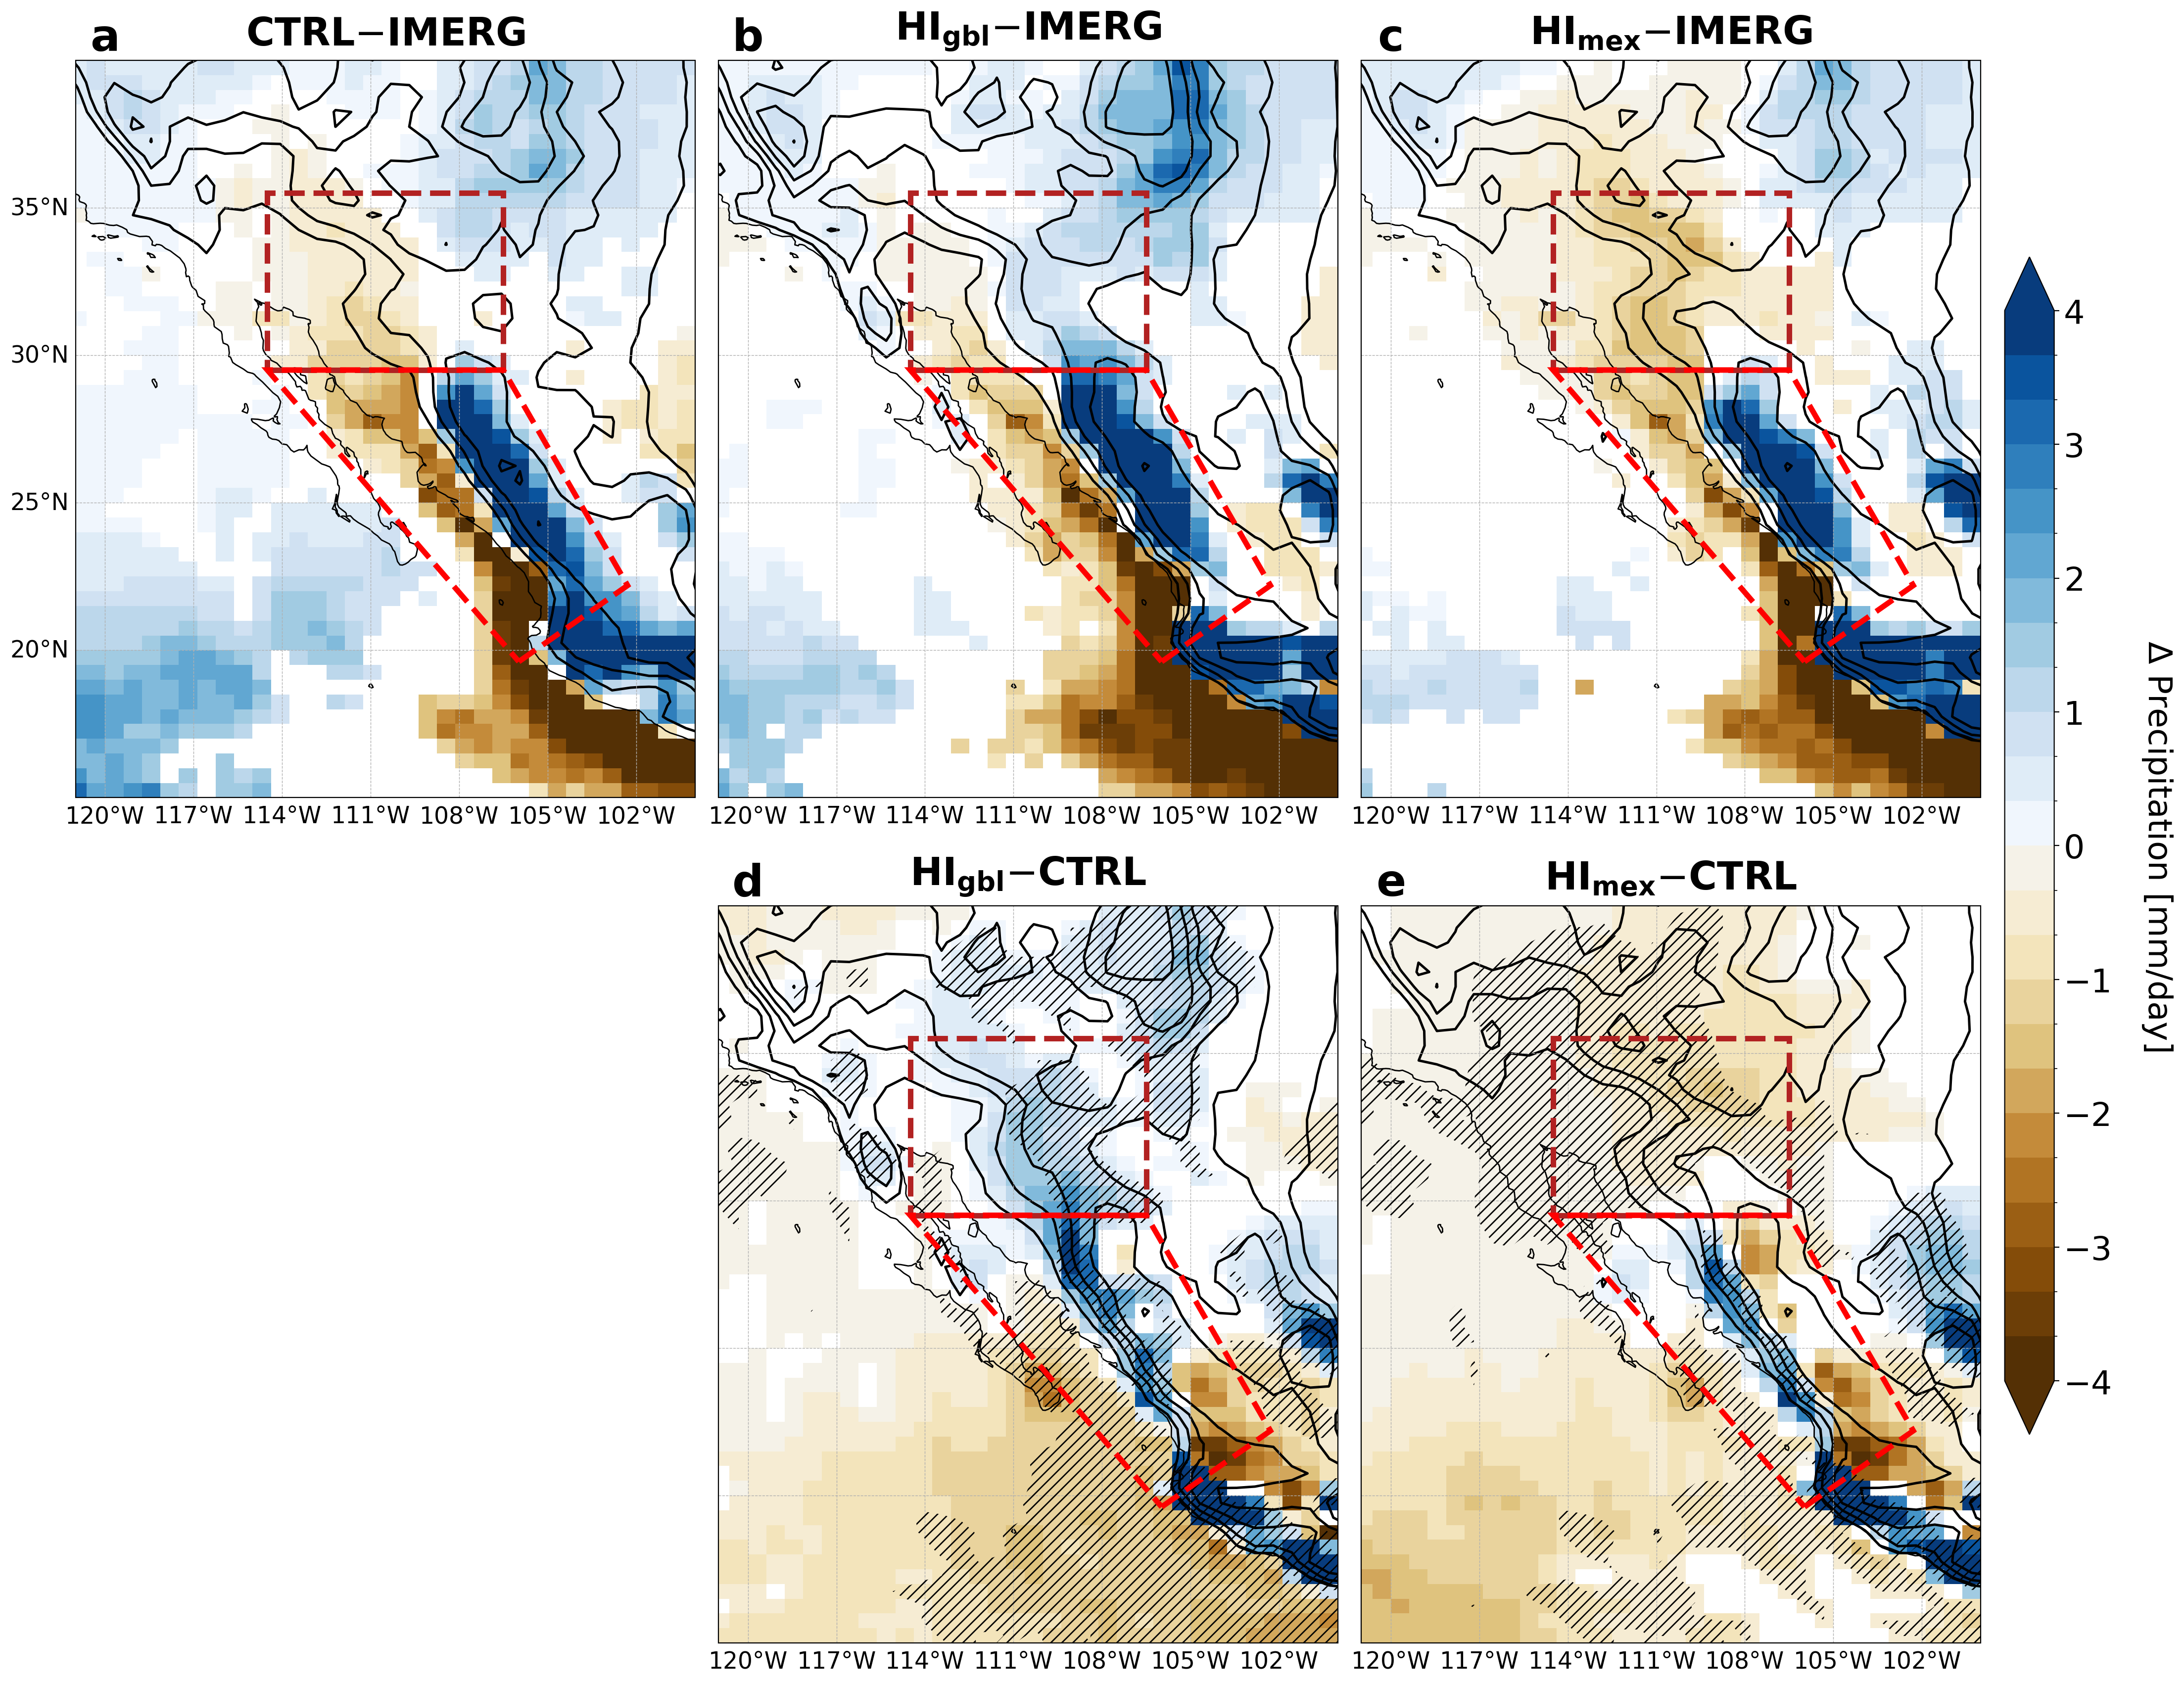

In [31]:
# --- settings --- #
text_kw={'color':'k', 'weight':'bold', 'size':28, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':32, 'ha':'center', 'va':'center'}
row1_titles=np.array(['CTRL$-$IMERG', r'HI$_{\mathbf{gbl}}$$-$IMERG', r'HI$_{\mathbf{mex}}$$-$IMERG'])
row2_titles=np.array(['', r'HI$_{\mathbf{gbl}}$$-$CTRL', r'HI$_{\mathbf{mex}}$$-$CTRL'])
letters=list("abcdef")
tx=-110.5
ty=40.25
# var specs
lat=jas_mean['flor']['ctrl'].lat
lon=jas_mean['flor']['ctrl'].lon
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-4
dvmax=4
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(800,3800,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]

# --- plot --- #
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(20,17), layout='constrained', subplot_kw={'projection':proj})

# row 1: CTRL, HIgbl, HImex bias vs. IMERG
for c, run in enumerate(flor_runs):
    cf=ax[0,c].pcolormesh(lon, lat, diff_mask['imerg'][run], cmap=dcmap, norm=dnorm, transform=trans)
    ax[0,c].contour(lon, lat, topo[run], levels=zlevels, linewidths=1.8, colors='black', transform=trans)

# row 2: topography sensitivity (HIgbl-CTRL, HImex-CTRL)
ax[1,0].axis('off')
for c, run in enumerate(['hitopo','hicam']):
    col = c + 1
    ax[1,col].pcolormesh(lon, lat, model_diff_mask[run], cmap=dcmap, norm=dnorm, transform=trans)
    ax[1,col].contour(lon, lat, topo[run], levels=zlevels, linewidths=1.8, colors='black', transform=trans)
    ax[1,col].contourf(lon, lat, bias_change_masked['imerg'][run],
                       0, colors='none', hatches=['','///'], extend='lower', zorder=100, transform=trans)

# --- formatting --- #
letter_i = 0
for r in range(2):
    for c in range(3):
        if r == 1 and c == 0:
            continue
        a = ax[r,c]
        poly1 = patches.Polygon(coords_map['north'], closed=True, ec='firebrick', fc='none', lw=4, ls='--',
                                 transform=ccrs.PlateCarree(), zorder=100)
        a.add_patch(poly1)
        poly2 = patches.Polygon(coords_map['south'], closed=True, ec='red', fc='none', lw=4, ls='--',
                                 transform=ccrs.PlateCarree(), zorder=100)
        a.add_patch(poly2)
        title = row1_titles[c] if r == 0 else row2_titles[c]
        a.text(tx, ty, title, **text_kw)
        a.text(-120, ty+0.5, letters[letter_i], **text_kw2)
        letter_i += 1
        a.coastlines(color='k', linewidth=1)
        #a.add_feature(cfeature.STATES, edgecolor='k', linewidth=.8)
        #a.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.8)
        a.set_extent(map_bnds, crs=trans)
        gl=a.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
        gl.bottom_labels=True; gl.left_labels=(c in [0,4]); gl.top_labels=False; gl.right_labels=False
        gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
        gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':17}
        gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':17}

# --- colorbar --- #
cax=fig.add_axes([1.01, 0.15, 0.025, 0.7])
cbar=fig.colorbar(cf, ticks=[-4,-3,-2,-1,0,1,2,3,4], orientation='vertical', extend='both', cax=cax)
cbar.set_label('$\Delta$ Precipitation [mm/day]', labelpad=45, rotation=270, size=24, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=24)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

# --- output --- #
plt.savefig('../figs/prec_flor_pi_imerg-bias_and_topo-sensitivity.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../figs/prec_flor_pi_imerg-bias_and_topo-sensitivity.png', transparent=False, bbox_inches='tight')

### Plot against all precipitation products

In [ ]:
# --- settings --- #
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
titles=np.array(['CTRL$-$OBS', r'HI$_{\mathbf{gbl}}$$-$CTRL', r'HI$_{\mathbf{mex}}$$-$CTRL'])
letters = list("ABCDEFGHIJKLMN"); letter_i = 0
tx=-110.5
ty=40.25
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(800,3800,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]

# --- plot --- #
nrows = len(obs_prods)
ncols = 3
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5.5*nrows),
                       layout='constrained', subplot_kw={'projection': proj})

lat=jas_mean['flor']['ctrl'].lat
lon=jas_mean['flor']['ctrl'].lon

for r, prod in enumerate(obs_prods):

    # ctrl - obs bias
    cf = ax[r,0].pcolormesh(lon, lat, diff_mask[prod]['ctrl'], cmap=dcmap, norm=dnorm, transform=trans)
    ax[r,0].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1.3, colors='k', transform=trans)
    ax[r,0].text(-125, 27, prod.upper(), rotation=90, va='center', **text_kw)

    # topography sensitivity
    for c, run in enumerate(['hitopo', 'hicam']):
        col = c + 1
        ax[r,col].pcolormesh(lon, lat, model_diff_mask[run], cmap=dcmap, norm=dnorm, transform=trans)
        ax[r,col].contourf(lon, lat, bias_change_masked[prod][run],
                           0, colors='none', hatches=['','///'], extend='lower', zorder=100, transform=trans)
        ax[r,col].contour(lon, lat, topo[run], levels=zlevels, linewidths=1.3, colors='black', transform=trans)

    # labels
    for c in range(ncols):
        ax[r,c].text(-121, ty+0.6, letters[letter_i], **text_kw2)
        letter_i += 1
        if r == 0:
            ax[r,c].text(tx, ty, titles[c], va='bottom', **text_kw)

# --- formatting --- #
for r in range(nrows):
    for c in range(ncols):
        a = ax[r,c]
        a.add_patch(patches.Polygon(coords_map['north'], closed=True, ec='firebrick', fc='none', lw=2.5, ls='--',
                                    transform=ccrs.PlateCarree(), zorder=100))
        a.add_patch(patches.Polygon(coords_map['south'], closed=True, ec='red', fc='none', lw=2.5, ls='--',
                                    transform=ccrs.PlateCarree(), zorder=100))
        a.coastlines(color='k', linewidth=0.8)
        a.add_feature(cfeature.STATES, edgecolor='k', linewidth=0.8)
        a.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=0.8)
        if i==9:
            a.add_feature(cfeature.OCEAN, facecolor='grey', zorder=100)
        a.set_extent(map_bnds, crs=trans)
        gl = a.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
        gl.bottom_labels=(r == nrows - 1); gl.left_labels=(c == 0); gl.top_labels=False; gl.right_labels=False
        gl.xformatter = LONGITUDE_FORMATTER; gl.yformatter = LATITUDE_FORMATTER
        gl.xlabel_style = {'size':14}; gl.ylabel_style = {'size':14}

# --- colorbar --- #
cax = fig.add_axes([.15, -0.021, 0.7, 0.0175])
cbar = fig.colorbar(cf, ticks=[-3,-2,-1,0,1,2,3], orientation='horizontal', extend='both', cax=cax)
cbar.set_label('$\Delta$ Precipitation [mm/day]', labelpad=5, size=18)
cbar.ax.tick_params(labelsize=18)

# --- output --- #
plt.savefig('../figs/prec_flor_pi_all-obs-prods-bias_change.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../figs/prec_flor_pi_all-obs-prods-bias_change.png', transparent=False, bbox_inches='tight')

### Comparison of CTRL, HIgbl, and HImex Biases Against All Precipitation Products

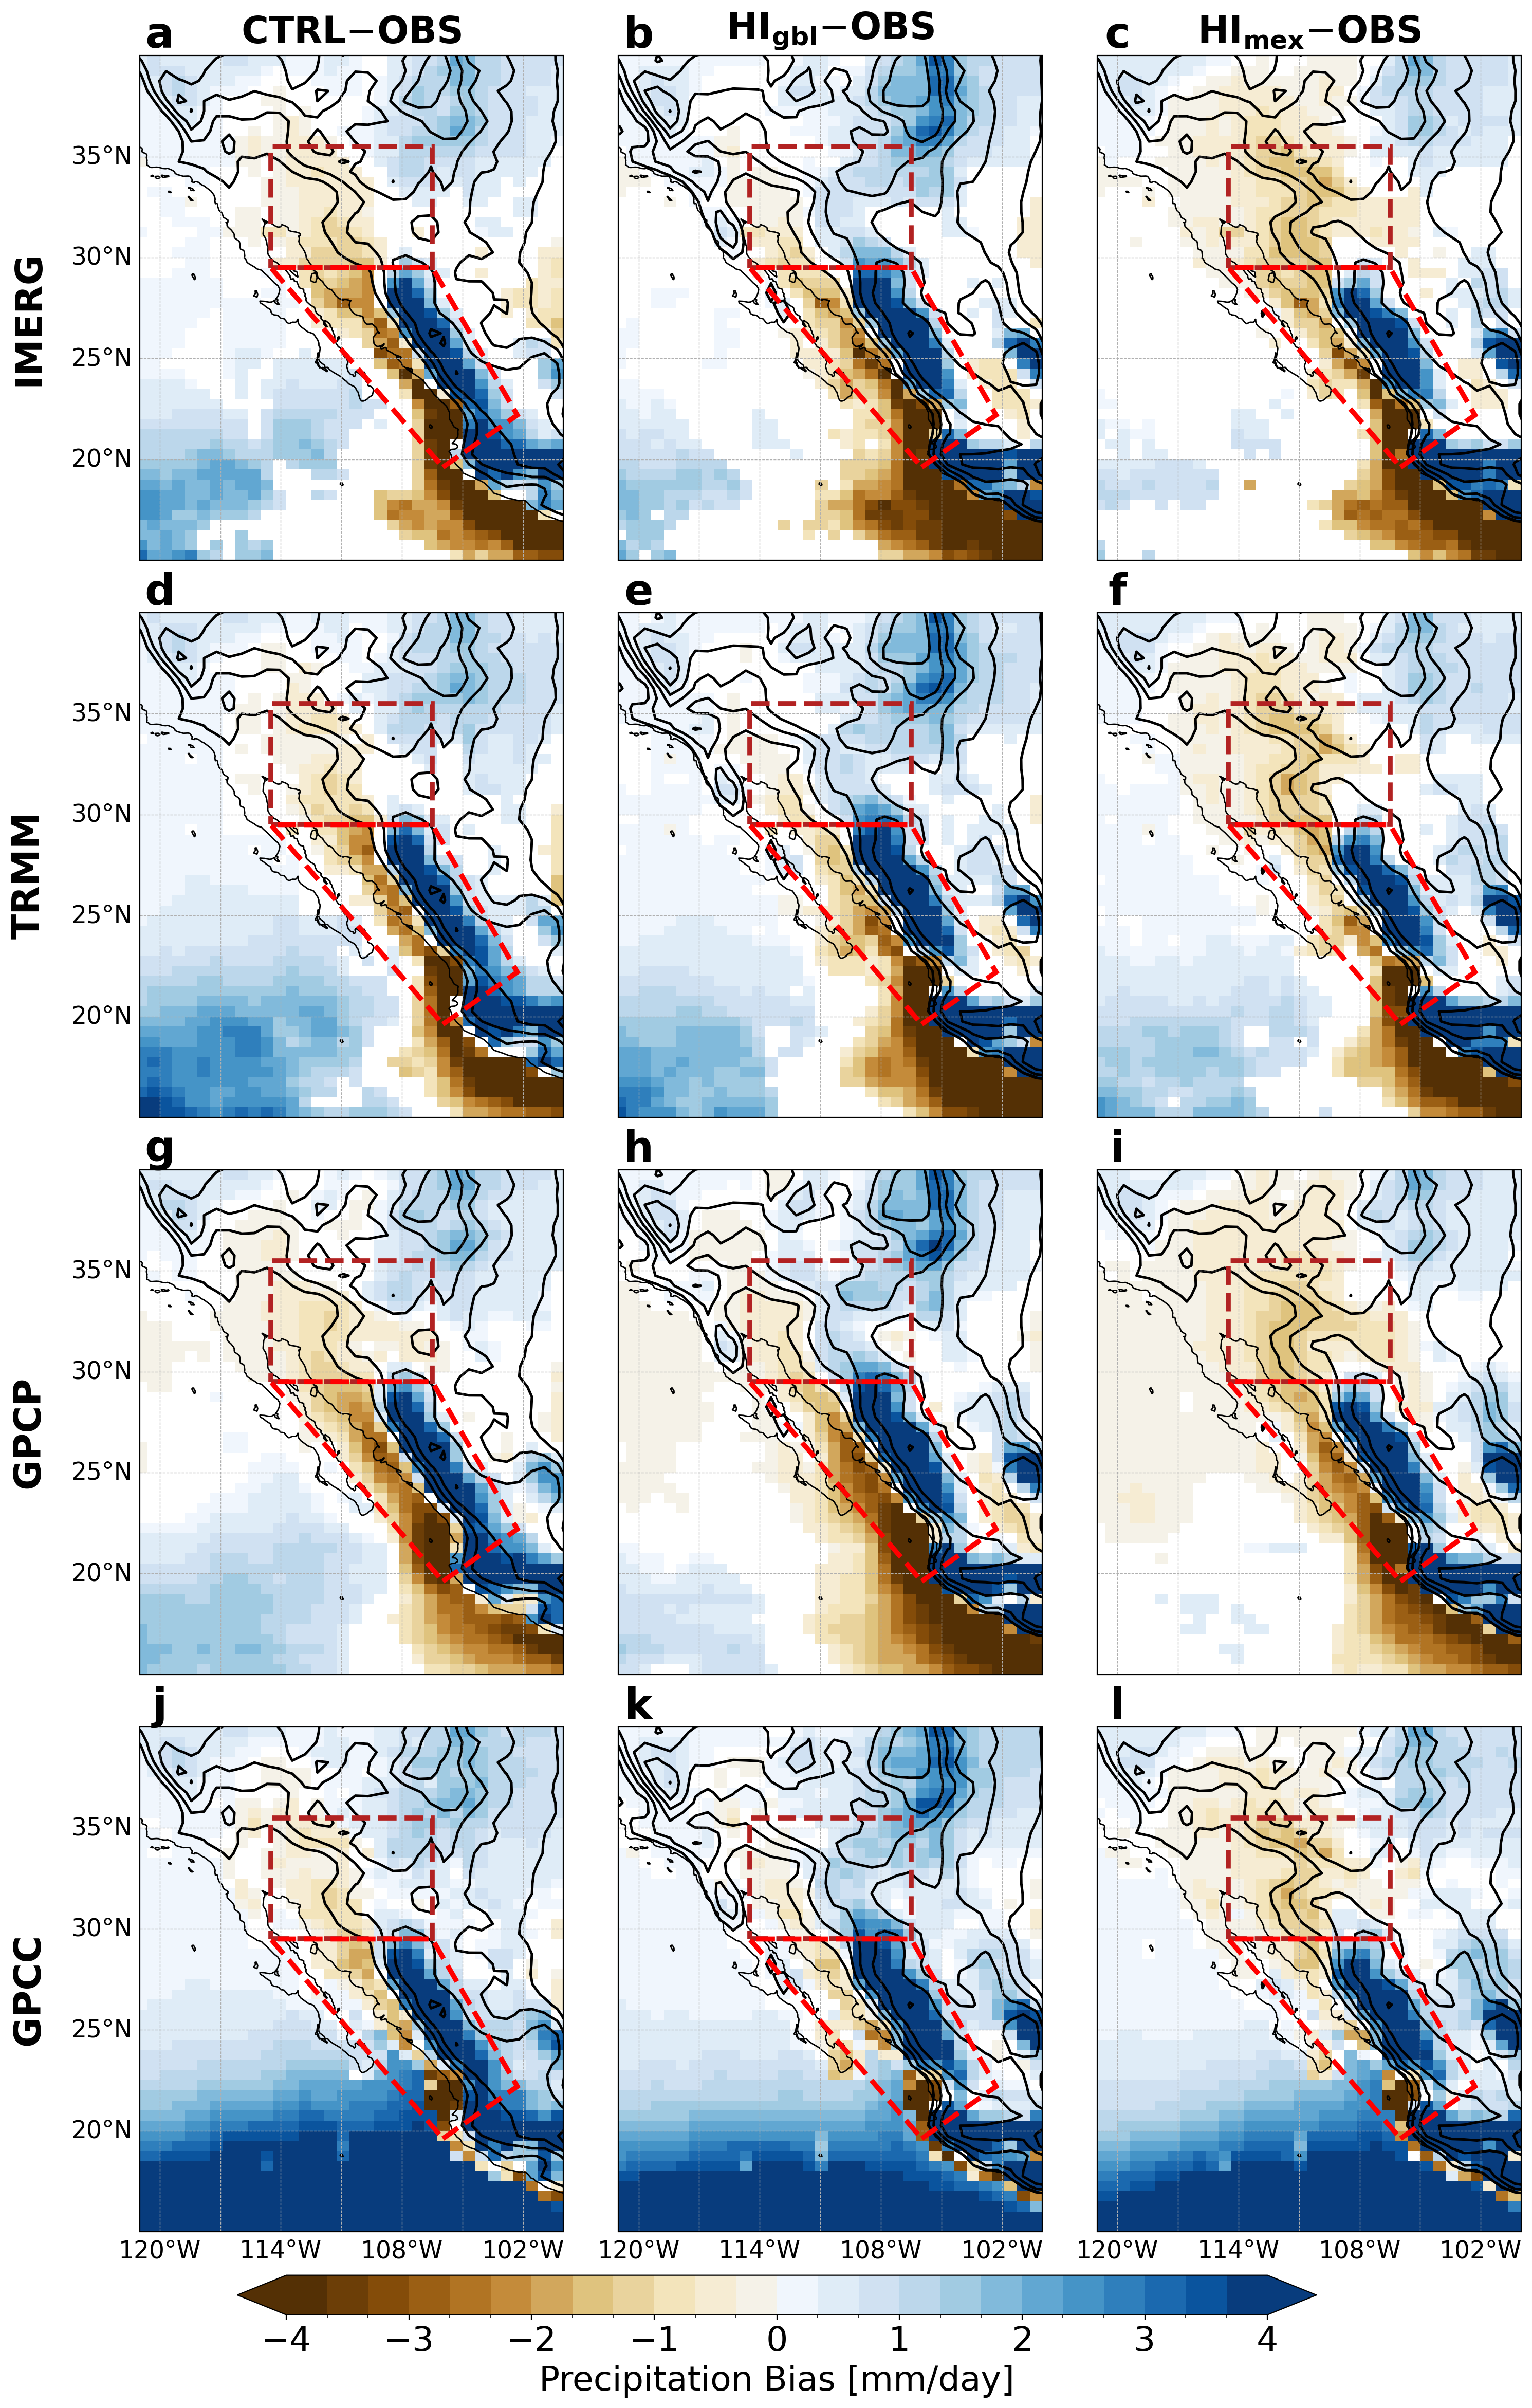

In [36]:
# --- settings --- #
text_kw={'color':'k', 'weight':'bold', 'size':26, 'ha':'center'}
text_kw2={'color':'k', 'weight':'bold', 'size':30, 'ha':'center', 'va':'center'}
titles=np.array(['CTRL$-$OBS', r'HI$_{\mathbf{gbl}}$$-$OBS', r'HI$_{\mathbf{mex}}$$-$OBS'])
letters = list("abcdefghijklmn"); letter_i = 0
tx=-110.5
ty=40.25
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-4
dvmax=4
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(800,3800,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]

# --- plot --- #
nrows = len(obs_prods)
ncols = len(flor_runs)
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5.5*nrows),
                       layout='constrained', subplot_kw={'projection': proj})

lat=jas_mean['flor']['ctrl'].lat
lon=jas_mean['flor']['ctrl'].lon

for r, prod in enumerate(obs_prods):

    # model config bias vs. obs product
    for c, run in enumerate(flor_runs):
        cf = ax[r,c].pcolormesh(lon, lat, diff_mask[prod][run], cmap=dcmap, norm=dnorm, transform=trans)
        ax[r,c].contour(lon, lat, topo[run], levels=zlevels, linewidths=1.8, colors='k', transform=trans)
    ax[r,0].text(-126.5, 27, prod.upper(), rotation=90, va='center', **text_kw)

    # labels
    for c in range(ncols):
        ax[r,c].text(-120, ty+0.75, letters[letter_i], **text_kw2)
        letter_i += 1
        if r == 0:
            ax[r,c].text(tx, ty, titles[c], va='bottom', **text_kw)

# --- formatting --- #
for r in range(nrows):
    for c in range(ncols):
        a = ax[r,c]
        a.add_patch(patches.Polygon(coords_map['north'], closed=True, ec='firebrick', fc='none', lw=3.5, ls='--',
                                    transform=ccrs.PlateCarree(), zorder=100))
        a.add_patch(patches.Polygon(coords_map['south'], closed=True, ec='red', fc='none', lw=3.5, ls='--',
                                    transform=ccrs.PlateCarree(), zorder=100))
        a.coastlines(color='k', linewidth=1)
        #a.add_feature(cfeature.STATES, edgecolor='k', linewidth=1)
        #a.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=0.8)
        a.set_extent(map_bnds, crs=trans)
        gl = a.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
        gl.bottom_labels=(r == nrows - 1); gl.left_labels=(c == 0); gl.top_labels=False; gl.right_labels=False
        gl.xformatter = LONGITUDE_FORMATTER; gl.yformatter = LATITUDE_FORMATTER
        gl.xlabel_style = {'size':17}; gl.ylabel_style = {'size':17}

# --- colorbar --- #
cax = fig.add_axes([.15, -0.021, 0.7, 0.0175])
cbar = fig.colorbar(cf, ticks=[-4,-3,-2,-1,0,1,2,3,4], orientation='horizontal', extend='both', cax=cax)
cbar.set_label('Precipitation Bias [mm/day]', labelpad=5, size=24)
cbar.ax.tick_params(labelsize=24)

# --- output --- #
#plt.savefig('../figs/prec_flor_pi_all-obs-prods_all-configs-bias.pdf', transparent=False, bbox_inches='tight')
#plt.savefig('../figs/prec_flor_pi_all-obs-prods_all-configs-bias.png', transparent=False, bbox_inches='tight')